> Copyright © 2026 Agnès REGAUD  
> Licence : [GNU Affero General Public License v3.0](../LICENSE) — `SPDX-License-Identifier: AGPL-3.0-only`

# Notebook 2 — Benchmark des modèles de détection d’anomalies PCB

## Plan :
**1. Introduction**
  - But du notebook
  - Modèles comparés
  - Critères de comparaison

**2. Chargement de la configuration et préparation**
  - Imports
  - Lecture de `config.yml`
  - Lecture de `data.yaml`
  - Initialisation des chemins, classes et paramètres globaux
  - Fixation du seed

**3. Définition du benchmark**
  - Modèles retenus
  - Paramètres d’entraînement
  - Métriques suivies

**4. Fonctions utilitaires du benchmark**
  - Chargement de la configuration
  - Initialisation de MLflow
  - Fonction de lancement d’un entraînement par modèle
  - Fonction de collecte / harmonisation des métriques
    
**5. Entraînement et suivi des expérimentations**
  - Boucle d'entraînement des modèles
  - Récupération et mise en forme des résultats
  - Ajustement des hyperparamètres de YOLOv8s

**6. Comparaison des résultats**
  - Comparaison visuelle des métriques
  - Analyse des écarts entre modèles
  - Comparaison des configurations testées pour YOLOv8s

**7. Sélection du modèle final**
  - Modèle retenu
  - Justification du choix
  - Analyse du modèle retenu

**8. Évaluation finale sur le jeu de test**
  - Métriques finales
  - Matrice de confusion
  - Performance par classe

**9. Préparation des images pour la démonstration live**
  - Sélection de 2 images par classe

**10. Mise à jour des ressources du dashboard**
  - Copie des métriques et visuels vers Streamlit

# 1. Introduction
- **But du notebook :** comparer plusieurs modèles de détection d’objets sur le dataset **PCB Defect Dataset** afin d’identifier le modèle le plus pertinent pour détecter automatiquement des anomalies sur des cartes électroniques.
- **Modèles comparés :** `yolov8s`,`faster_rcnn_resnet50_fpn`.
- **Source de configuration :** le notebook s’appuie sur `config.yml` pour les paramètres généraux du projet et sur `data.yaml` pour la description du dataset.
- **Critère principal de comparaison :** `mAP50-95` comme critère principal, complété par `mAP50`, le temps d’entraînement et le temps d’inférence.
- **Ajustement complémentaire** : après la comparaison initiale, plusieurs configurations de yolov8s sont testées en faisant varier certains hyperparamètres (epochs, learning_rate, batch_size) afin de retenir la meilleure configuration finale.
- **Suivi des expérimentations :** les runs sont tracés avec **MLflow** ; les artefacts d’entraînement sont conservés dans `outputs/models/` et le meilleur modèle YOLO est copié sous un nom stable.

# 2. Chargement de la configuration et préparation

## 2.1 Imports

In [1]:
from ultralytics import YOLO

from pathlib import Path
from typing import Any
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import yaml
import mlflow
import shutil
import sys
from collections import defaultdict


/Users/agnes/anaconda3/envs/pcb-defect-detection_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2.2 Chargement de la configuration et des chemins du projet

In [2]:
# Configuration
def load_yaml_file(file_path: Path) -> dict[str, Any]:
    """Load a YAML file and return its content."""
    with open(file_path, "r", encoding="utf-8") as file:
        return yaml.safe_load(file)


def set_random_seed(seed: int) -> None:
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)


project_root: Path = Path("..")
sys.path.insert(0, str(project_root.resolve()))

from src.utils import resolve_device

config_path: Path = project_root / "config.yml"

config: dict[str, Any] = load_yaml_file(config_path)

dataset_root: Path = (
    project_root
    / config["dataset"]["root_dir"]
)
dataset_yaml_path: Path = dataset_root / "data.yaml"

experiment_root: Path = project_root / "outputs"
metrics_dir: Path = experiment_root / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

data_config: dict[str, Any] = load_yaml_file(dataset_yaml_path)

random_seed: int = config["project"]["random_seed"]
set_random_seed(random_seed)

class_mapping: dict[int, str] = data_config["names"]
class_names: list[str] = [class_mapping[i] for i in sorted(class_mapping)]
num_classes: int = len(class_names)

print(f"Dataset root: {dataset_root}")
print(f"Dataset YAML: {dataset_yaml_path}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

Dataset root: ../data/processed/pcb-defect-dataset
Dataset YAML: ../data/processed/pcb-defect-dataset/data.yaml
Number of classes: 6
Classes: ['mouse_bite', 'spur', 'missing_hole', 'short', 'open_circuit', 'spurious_copper']


In [3]:
dataset_counts: dict[str, dict[str, int]] = {}

for split in ["train", "val", "test"]:
    images_dir = dataset_root / split / "images"
    labels_dir = dataset_root / split / "labels"

    image_count = len(
        list(images_dir.glob("*.jpg"))
    )
    label_count = len(
        list(labels_dir.glob("*.txt"))
    )

    dataset_counts[split] = {
        "images": image_count,
        "labels": label_count,
    }

    print(
        split,
        "| images :", image_count,
        "| labels :", label_count,
    )

train | images : 8500 | labels : 8500
val | images : 266 | labels : 266
test | images : 266 | labels : 266


## 2.3 Lecture de data.yaml et extraction des informations du dataset

In [4]:
config_summary: pd.DataFrame = pd.DataFrame(
    {
        "parameter": [
            "random_seed",
            "dataset_name",
            "dataset_root_dir",
            "selected_models",
            "image_size",
            "epochs",
            "device",
            "num_workers",
        ],
        "value": [
            config["project"]["random_seed"],
            config["dataset"]["name"],
            str(dataset_root),
            ", ".join(config["benchmark"]["selected_models"]),
            config["training"]["image_size"],
            config["training"]["epochs"],
            config["training"]["device"],
            config["training"]["num_workers"],
        ],
    }
)

config_summary

,parameter,value
0,random_seed,42
1,dataset_name,pcb_defect_dataset
2,dataset_root_dir,../data/processed/pcb-defect-dataset
3,selected_models,"yolov8s, faster_rcnn_resnet50_fpn"
4,image_size,640
5,epochs,10
6,device,auto
7,num_workers,4


In [5]:
# Dataset summary
data_summary: pd.DataFrame = pd.DataFrame(
    {
        "parameter": ["dataset_yaml_path", "num_classes", "class_names"],
        "value": [
            str(dataset_yaml_path),
            num_classes,
            ", ".join(class_names),
        ],
    }
)

data_summary

,parameter,value
0,dataset_yaml_path,../data/processed/pcb-defect-dataset/data.yaml
1,num_classes,6
2,class_names,"mouse_bite, spur, missing_hole, short, open_ci..."


## 2.4 Initialisation et vérification des chemins du projet

In [6]:
train_images_dir: Path = dataset_root / "train" / "images"
train_labels_dir: Path = dataset_root / "train" / "labels"
val_images_dir: Path = dataset_root / "val" / "images"
val_labels_dir: Path = dataset_root / "val" / "labels"
test_images_dir: Path = dataset_root / "test" / "images"
test_labels_dir: Path = dataset_root / "test" / "labels"

paths_summary: pd.DataFrame = pd.DataFrame(
    {
        "path_name": [
            "dataset_root",
            "dataset_yaml_path",
            "train_images_dir",
            "train_labels_dir",
            "val_images_dir",
            "val_labels_dir",
            "test_images_dir",
            "test_labels_dir",
        ],
        "path_value": [
            str(dataset_root),
            str(dataset_yaml_path),
            str(train_images_dir),
            str(train_labels_dir),
            str(val_images_dir),
            str(val_labels_dir),
            str(test_images_dir),
            str(test_labels_dir),
        ],
        "exists": [
            dataset_root.exists(),
            dataset_yaml_path.exists(),
            train_images_dir.exists(),
            train_labels_dir.exists(),
            val_images_dir.exists(),
            val_labels_dir.exists(),
            test_images_dir.exists(),
            test_labels_dir.exists(),
        ],
    }
)

paths_summary

,path_name,path_value,exists
0,dataset_root,../data/processed/pcb-defect-dataset,True
1,dataset_yaml_path,../data/processed/pcb-defect-dataset/data.yaml,True
2,train_images_dir,../data/processed/pcb-defect-dataset/train/images,True
3,train_labels_dir,../data/processed/pcb-defect-dataset/train/labels,True
4,val_images_dir,../data/processed/pcb-defect-dataset/val/images,True
5,val_labels_dir,../data/processed/pcb-defect-dataset/val/labels,True
6,test_images_dir,../data/processed/pcb-defect-dataset/test/images,True
7,test_labels_dir,../data/processed/pcb-defect-dataset/test/labels,True


# 3. Définition du benchmark

## 3.1 Modèles retenus

In [7]:
selected_models: list[str] = config["benchmark"]["selected_models"]
baseline_model: str = config["benchmark"]["baseline_model"]
primary_model: str = config["benchmark"]["primary_model"]

models_summary: pd.DataFrame = pd.DataFrame(
    {
        "parameter": ["selected_models", "baseline_model", "primary_model"],
        "value": [
            ", ".join(selected_models),
            baseline_model,
            primary_model,
        ],
    }
)

models_summary

,parameter,value
0,selected_models,"yolov8s, faster_rcnn_resnet50_fpn"
1,baseline_model,faster_rcnn_resnet50_fpn
2,primary_model,yolov8s


## 3.2 Paramètres d’entraînement

In [8]:
training_config: dict[str, Any] = config["training"]

training_params_summary: pd.DataFrame = pd.DataFrame(
    {
        "parameter": [
            "image_size",
            "yolov8s_epochs",
            "faster_rcnn_epochs",
            "device",
            "num_workers",
            "horizontal_flip",
            "vertical_flip",
            "rotation_degrees",
            "primary_selection_metric",
            "secondary_selection_metric",
            "tertiary_selection_metric",
            "reported_additional_metrics",
            "faster_rcnn_train_subset",
        ],
        "value": [
            training_config["image_size"],
            config["training"]["epochs"],
            config["models"]["faster_rcnn_resnet50_fpn"]["epochs"],
            training_config["device"],
            training_config["num_workers"],
            training_config["augmentation"]["horizontal_flip"],
            training_config["augmentation"]["vertical_flip"],
            training_config["augmentation"]["rotation_degrees"],
            "mAP50-95",
            "inference_time",
            "mAP50",
            "training_time, inference_time",
            config["models"]["faster_rcnn_resnet50_fpn"]["train_subset_size"],
        ],
    }
)

training_params_summary

,parameter,value
0,image_size,640
1,yolov8s_epochs,10
2,faster_rcnn_epochs,1
3,device,auto
4,num_workers,4
5,horizontal_flip,0.5
6,vertical_flip,0.0
7,rotation_degrees,5
8,primary_selection_metric,mAP50-95
9,secondary_selection_metric,inference_time


### Configuration d’entraînement utilisée

- **YOLOv8s baseline** : entraînement sur le split `train` défini dans `data.yaml`, avec les paramètres de `config.yml`.
- **Faster R-CNN** : entraînement limité à un échantillon stratifié de **3 000 images train**, avec la graine **42**, afin de conserver un temps d’exécution raisonnable en local, puis évaluation sur les **266 images de validation**, comme YOLOv8s.
- **Faster R-CNN** est forcé en `cpu`, avec `epochs=1`, `batch_size=2` et `num_workers=0`.
- Les deux modèles sont comparés avec les mêmes métriques finales : `mAP50-95`, `mAP50`, `training_time`, `inference_time`.

In [9]:
model_training_rows: list[dict[str, Any]] = []

for model_name in config["benchmark"]["selected_models"]:
    model_cfg: dict[str, Any] = config["models"][model_name]

    model_training_rows.append(
        {
            "model_name": model_name,
            "pretrained": model_cfg["pretrained"],
            "batch_size": model_cfg["batch_size"],
            "optimizer": model_cfg["optimizer"],
            "learning_rate": model_cfg["learning_rate"],
            "weight_decay": model_cfg["weight_decay"],
        }
    )

model_training_summary: pd.DataFrame = pd.DataFrame(model_training_rows)
model_training_summary

,model_name,pretrained,batch_size,optimizer,learning_rate,weight_decay
0,yolov8s,True,16,adamw,0.001,0.0005
1,faster_rcnn_resnet50_fpn,True,2,sgd,0.005,0.0005


## 3.3 Métriques suivies

### Rappel des métriques de détection

- **IoU (Intersection over Union)** : mesure le chevauchement entre une bounding box prédite et une bounding box réelle.  
  Plus l’IoU est élevé, plus la localisation est précise.

- **AP (Average Precision)** : score calculé pour une classe donnée, qui résume la courbe precision-recall pour un seuil d’IoU fixé.

- **mAP (mean Average Precision)** : moyenne des AP sur l’ensemble des classes.

- **mAP50** : mAP calculée avec un seuil d’IoU de 0.50.

- **mAP50-95** : moyenne des mAP calculées sur plusieurs seuils d’IoU, de 0.50 à 0.95.  
  Cette métrique est plus exigeante et constitue le critère principal retenu pour comparer les modèles dans ce benchmark.

- **Temps d’inférence** : temps moyen nécessaire pour traiter une image en phase de validation.
Cette métrique permet d’évaluer le compromis entre performance de détection et rapidité d’exécution.

**--> Métriques retenues pour comparaison** : 
- **Critère principal de sélection :** `mAP50-95`
- **Critère secondaire :** temps d’inférence
- **Critère tertiaire :** `mAP50`
- **Métriques affichées dans le tableau comparatif :** `mAP50-95`, `mAP50`, `training_time`, `inference_time`
- **Analyse complémentaire :** AP par classe

# 4. Fonctions utilitaires du benchmark

## 4.1 Initialisation de MLflow

In [10]:
mlflow.set_tracking_uri((project_root / "mlruns").resolve().as_uri())
print(mlflow.get_tracking_uri())

file:///Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing%20Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/mlruns


## 4.2 Import des fonctions utilitaires du benchmark

In [11]:
from src.modeling import (
    format_benchmark_result,
    is_better_result,
    log_run_to_mlflow,
    train_model,
)

## 4.3 Rôle des fonctions utilitaires

### --> Les fonctions utilitaires du benchmark sont définies dans `src/modeling.py` puis importées dans ce notebook pour piloter les entraînements, harmoniser les résultats, suivre les runs avec MLflow et sauvegarder le meilleur modèle.

# 5. Entraînement et suivi des expérimentations

## 5.1 Boucle d’entraînement des modèles

In [12]:
# Use a dedicated MLflow experiment for the final clean runs.
mlflow.set_experiment("pcb_defect_benchmark_final")

/Users/agnes/anaconda3/envs/pcb-defect-detection_env/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location=('file:///Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing '
 'Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/notebooks/../mlruns/508302271126779451'), creation_time=1785321340958, experiment_id='508302271126779451', last_update_time=1785321340958, lifecycle_stage='active', name='pcb_defect_benchmark_final', tags={}, workspace='default'>

In [13]:
benchmark_results: list[dict[str, Any]] = []

selected_models: list[str] = config["benchmark"]["selected_models"]

outputs_dir: Path = experiment_root / "models"

outputs_dir.mkdir(parents=True, exist_ok=True)


for model_name in selected_models:
    print(f"\n=== Training {model_name} ===")

    model_config: dict[str, Any] = config["models"][model_name].copy()
    training_config: dict[str, Any] = config["training"].copy()
    training_config["random_seed"] = random_seed

    training_config["device"] = resolve_device(training_config["device"])

    if model_name == "faster_rcnn_resnet50_fpn":
        training_config["device"] = "cpu" if model_config["force_cpu"] else training_config["device"]
        training_config["num_workers"] = model_config["num_workers"]
        training_config["epochs"] = model_config["epochs"]

    raw_metrics: dict[str, Any] = train_model(
        model_name=model_name,
        data_yaml_path=dataset_yaml_path,
        training_config=training_config,
        model_config=model_config,
        outputs_dir=outputs_dir,
    )

    benchmark_result: dict[str, Any] = format_benchmark_result(
        model_name=model_name,
        raw_metrics=raw_metrics,
    )
    benchmark_results.append(benchmark_result)
    train_images_count = min(
        model_config.get(
            "train_subset_size",
            dataset_counts["train"]["images"],
        ),
        dataset_counts["train"]["images"],
    )

    log_run_to_mlflow(
        model_name=model_name,
        epochs=training_config["epochs"],
        batch_size=model_config["batch_size"],
        image_size=training_config["image_size"],
        random_seed=training_config["random_seed"],
        device=str(training_config["device"]),
        train_images=train_images_count,
        validation_images=dataset_counts["val"]["images"],
        metrics=benchmark_result,
        artifact_dir=outputs_dir / model_name,
    )


benchmark_results_df: pd.DataFrame = pd.DataFrame(benchmark_results)[
    ["model_name", "map50_95", "map50", "training_time", "inference_time"]
]



=== Training yolov8s ===
New https://pypi.org/project/ultralytics/8.4.123 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.26 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/processed/pcb-defect-dataset/data.yaml, degrees=5, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scal

## 5.2 Récupération et mise en forme des résultats

In [14]:
tracking_uri: str = mlflow.get_tracking_uri()
print(f"MLflow tracking URI: {tracking_uri}")

MLflow tracking URI: file:///Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing%20Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/mlruns


In [15]:
benchmark_results_df

,model_name,map50_95,map50,training_time,inference_time
0,yolov8s,0.575816,0.981634,3651.226630,0.006812
1,faster_rcnn_resnet50_fpn,0.376120,0.901574,3836.499389,0.502162


In [16]:
# Sauvegarde des résultats
benchmark_results_df.to_csv(metrics_dir / "benchmark_results.csv", index=False)

## 5.3 Ajustement des hyperparamètres de YOLOv8s

In [17]:
best_models_dir: Path = outputs_dir / "best"
best_models_dir.mkdir(parents=True, exist_ok=True)

yolo_tuning_results: list[dict[str, Any]] = [
    benchmark_results_df.loc[benchmark_results_df["model_name"] == "yolov8s"].iloc[0].to_dict()
]

yolo_experiments: list[dict[str, Any]] = [
    {
        "run_name": "yolov8s_epochs_20",
        "epochs": 20,
        "batch_size": config["models"]["yolov8s"]["batch_size"],
        "learning_rate": config["models"]["yolov8s"]["learning_rate"],
    },
    {
        "run_name": "yolov8s_lr_0.0005",
        "epochs": config["training"]["epochs"],
        "batch_size": config["models"]["yolov8s"]["batch_size"],
        "learning_rate": 0.0005,
    },
    {
        "run_name": "yolov8s_batch_8",
        "epochs": config["training"]["epochs"],
        "batch_size": 8,
        "learning_rate": config["models"]["yolov8s"]["learning_rate"],
    },
]

# Keep track of the best YOLO configuration found during tuning.
best_yolo_result: dict[str, Any] = yolo_tuning_results[0]
best_yolo_model_path: Path = outputs_dir / "yolov8s" / "weights" / "best.pt"

for experiment in yolo_experiments:
    print(f"\n=== Tuning run: {experiment['run_name']} ===")

    tuned_training_config: dict[str, Any] = config["training"].copy()
    tuned_training_config["random_seed"] = random_seed
    tuned_model_config: dict[str, Any] = config["models"]["yolov8s"].copy()

    tuned_training_config["device"] = resolve_device(tuned_training_config["device"])
    
    tuned_training_config["epochs"] = experiment["epochs"]
    tuned_model_config["batch_size"] = experiment["batch_size"]
    tuned_model_config["learning_rate"] = experiment["learning_rate"]

    raw_metrics: dict[str, Any] = train_model(
        model_name="yolov8s",
        data_yaml_path=dataset_yaml_path,
        training_config=tuned_training_config,
        model_config=tuned_model_config,
        outputs_dir=outputs_dir,
        run_name=experiment["run_name"],
    )

    benchmark_result: dict[str, Any] = format_benchmark_result(
        model_name=experiment["run_name"],
        raw_metrics=raw_metrics,
    )
    yolo_tuning_results.append(benchmark_result)

    log_run_to_mlflow(
        model_name=experiment["run_name"],
        epochs=tuned_training_config["epochs"],
        batch_size=tuned_model_config["batch_size"],
        image_size=tuned_training_config["image_size"],
        random_seed=tuned_training_config["random_seed"],
        device=str(tuned_training_config["device"]),
        train_images=dataset_counts["train"]["images"],
        validation_images=dataset_counts["val"]["images"],
        metrics=benchmark_result,
        artifact_dir=outputs_dir / experiment["run_name"],
    )
    # Update the best YOLO configuration if the current run is better.
    if is_better_result(benchmark_result, best_yolo_result):
        best_yolo_result = benchmark_result
        best_yolo_model_path = raw_metrics["model_path"]

# Save the final YOLO model under a stable name.

shutil.copy2(
    best_yolo_model_path,
    best_models_dir / "best_yolo_tuned.pt",
)


yolo_tuning_results_df: pd.DataFrame = pd.DataFrame(yolo_tuning_results)[
    ["model_name", "map50_95", "map50", "training_time", "inference_time"]
]


=== Tuning run: yolov8s_epochs_20 ===
New https://pypi.org/project/ultralytics/8.4.123 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.26 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/processed/pcb-defect-dataset/data.yaml, degrees=5, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.

In [18]:
yolo_tuning_results_df

,model_name,map50_95,map50,training_time,inference_time
0,yolov8s,0.575816,0.981634,3651.226630,0.006812
1,yolov8s_epochs_20,0.599150,0.980205,7146.712882,0.003878
2,yolov8s_lr_0.0005,0.568307,0.982152,3571.127902,0.003875
3,yolov8s_batch_8,0.559268,0.984254,3780.262244,0.018226


In [19]:
# Sauvegarde des résultats
yolo_tuning_results_df.to_csv(metrics_dir / "yolo_tuning_results.csv", index=False)

# 6. Comparaison des résultats

## 6.1 Comparaison visuelle des métriques

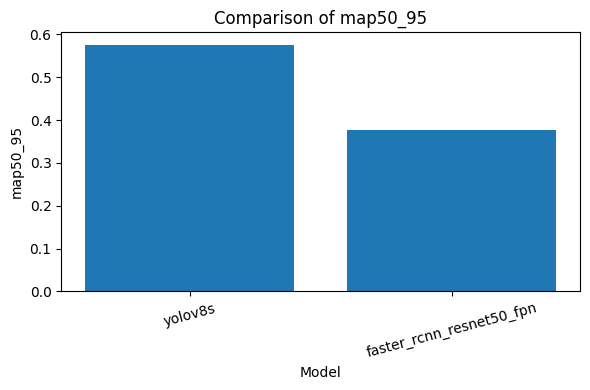

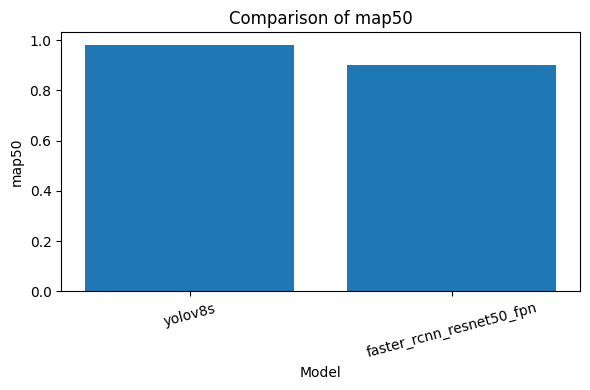

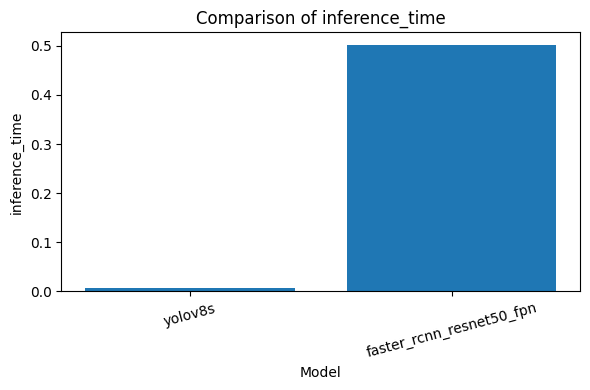

In [20]:
metrics_to_plot: list[str] = ["map50_95", "map50", "inference_time"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(benchmark_results_df["model_name"], benchmark_results_df[metric])
    plt.title(f"Comparison of {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## 6.2 Analyse des écarts entre modèles Yolo et FasterRCNN

### Conditions du benchmark

- YOLOv8s est entraîné sur les 8 500 images pendant 10 époques avec MPS, afin d’exploiter l’accélération disponible sur le Mac.
- Faster R-CNN est limité à 3 000 images stratifiées et une époque afin de conserver un temps d’exécution raisonnable. Il utilise le CPU pour garantir la stabilité de l’entraînement avec `torchvision`.
- Les deux modèles sont évalués sur les mêmes 266 images de validation.
- Les temps mesurés sur MPS et CPU ne sont donc pas directement comparables.

### Résultats observés

- YOLOv8s obtient de meilleurs scores de validation en `mAP50-95` et en `mAP50`.
- Son temps d’inférence observé est nettement inférieur à celui de Faster R-CNN, malgré les appareils différents.

### Conclusion

- Faster R-CNN permet de vérifier les performances de YOLOv8s face à une autre famille de modèles, mais son entraînement reste volontairement allégé.
- YOLOv8s est retenu pour ses meilleures performances de validation et sa rapidité d’inférence observée.

## 6.3 Comparaison des configurations testées pour YOLOv8s

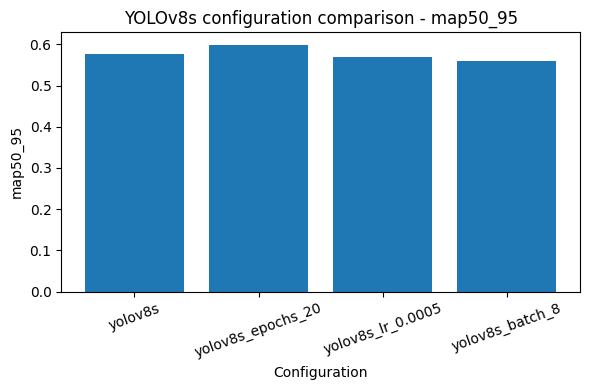

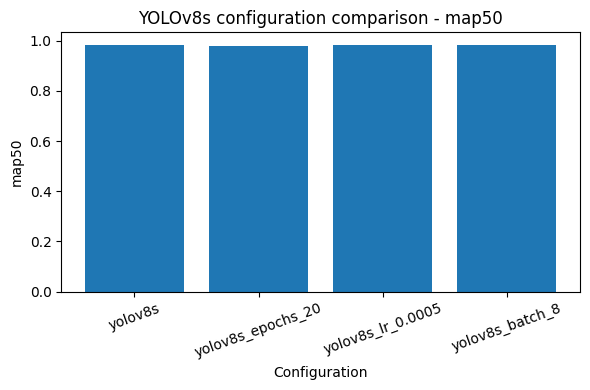

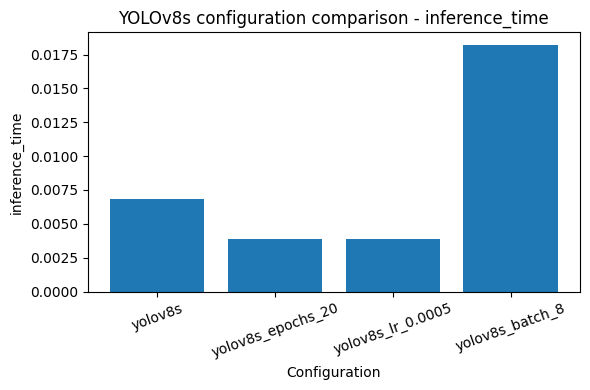

In [21]:
metrics_to_plot: list[str] = ["map50_95", "map50", "inference_time"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(yolo_tuning_results_df["model_name"], yolo_tuning_results_df[metric])
    plt.title(f"YOLOv8s configuration comparison - {metric}")
    plt.xlabel("Configuration")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

* L’augmentation à 20 époques donne le meilleur résultat global, avec la meilleure valeur de mAP50-95.
* La réduction du learning rate à 0.0005 ne présente pas de gain global : la mAP50 augmente très légèrement, mais la mAP50-95, métrique principale, diminue par rapport à la baseline.
* La diminution du batch size à 8 dégrade les performances, malgré un temps d’entraînement proche de la baseline.
* La configuration yolov8s_epochs_20 est donc retenue pour la suite du projet.

# 7 Sélection du modèle final

## 7.1 Modèle retenu

Le modèle retenu pour la suite du projet est yolov8s_epochs_20.

## 7.2 Justification du choix

- `yolov8s_epochs_20` obtient le meilleur `mAP50-95`, critère principal du benchmark.
- Il conserve un très bon `mAP50` et un temps d’inférence faible.
- YOLOv8s est plus adapté que Faster R-CNN pour une détection exploitable en application, notamment grâce à sa rapidité d’inférence.
- Cette configuration est donc retenue comme meilleur compromis entre performance et efficacité.

## 7.3. Analyse du modèle retenu

### 7.3.1. Training dynamics

#### Dynamique d’entraînement

Deux vues complémentaires sont utilisées pour analyser l’entraînement :

- **mAP de validation (mAP50-95, mAP50)** : mesure la performance du modèle au fil des époques et sert à sélectionner le meilleur modèle.
- **Loss totale (train et validation)** : somme des pertes de localisation, classification et distribution, donnant une vision globale de l’optimisation.

Cette combinaison permet de vérifier à la fois :
- la **performance** (via la mAP)
- la **convergence et la généralisation** (via l’évolution des losses)

In [22]:
print("best_yolo_result =", best_yolo_result)
print("best_yolo_tuned exists =", (best_models_dir / "best_yolo_tuned.pt").exists())

best_yolo_result = {'model_name': 'yolov8s_epochs_20', 'map50_95': 0.5991502578838942, 'map50': 0.9802051382304442, 'precision': 0.9685720374196493, 'recall': 0.9855453193109168, 'training_time': 7146.712881625048, 'inference_time': 0.0038781976883117586}
best_yolo_tuned exists = True


In [23]:
best_run_name = best_yolo_result["model_name"]
best_run_results_path = outputs_dir / best_run_name / "results.csv"

results_df = pd.read_csv(best_run_results_path)
results_df.columns = results_df.columns.str.strip()  # utile avec les CSV Ultralytics

In [24]:
# Total loss = box + classification + distribution focal loss
results_df["train/total_loss"] = (
    results_df["train/box_loss"]
    + results_df["train/cls_loss"]
    + results_df["train/dfl_loss"]
)

results_df["val/total_loss"] = (
    results_df["val/box_loss"]
    + results_df["val/cls_loss"]
    + results_df["val/dfl_loss"]
)

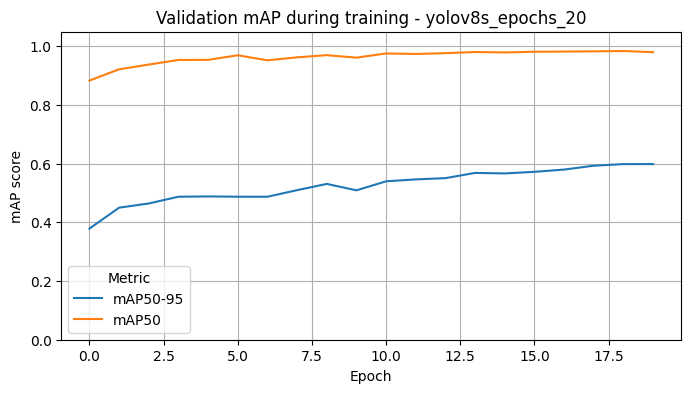

In [25]:
# Plot validation mAP
metrics_to_plot = results_df[
    ["metrics/mAP50-95(B)", "metrics/mAP50(B)"]
].rename(
    columns={
        "metrics/mAP50-95(B)": "mAP50-95",
        "metrics/mAP50(B)": "mAP50",
    }
)

metrics_to_plot.plot(figsize=(8, 4))
plt.title(f"Validation mAP during training - {best_run_name}")
plt.xlabel("Epoch")
plt.ylabel("mAP score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(title="Metric")
plt.show()

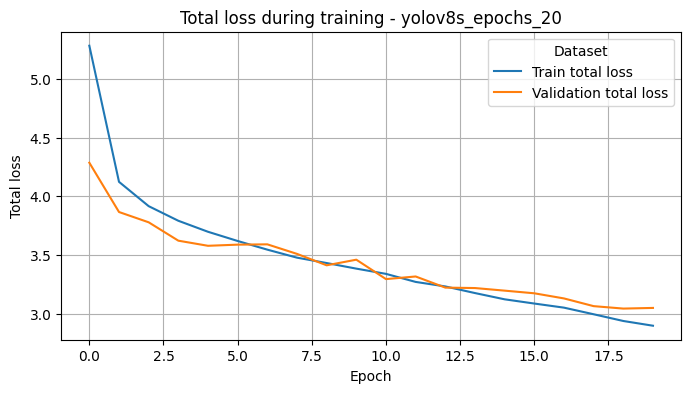

In [26]:
# Plot total training and validation loss
losses_to_plot = results_df[
    ["train/total_loss", "val/total_loss"]
].rename(
    columns={
        "train/total_loss": "Train total loss",
        "val/total_loss": "Validation total loss",
    }
)

losses_to_plot.plot(figsize=(8, 4))
plt.title(f"Total loss during training - {best_run_name}")
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.grid(True)
plt.legend(title="Dataset")
plt.show()

### Interprétation

- Les losses d’entraînement et de validation diminuent ensemble.
- La loss de validation se stabilise en fin d’entraînement sans hausse marquée.
- La mAP50-95 progresse jusqu’à environ `0,60`.
- Aucun surapprentissage net n’apparaît sur les 20 époques.

### 7.3.2. Confusion matrix on validation set

Cette matrice présente le comportement du modèle retenu sur le jeu de validation avec le seuil de confiance de l’application (`0,30`).

In [27]:
best_model = YOLO(str(best_models_dir / "best_yolo_tuned.pt"))

validation_dir = experiment_root / "predictions"

confusion_results = best_model.val(
    data=str(dataset_yaml_path),
    split="val",
    imgsz=config["inference"]["image_size"],
    conf=config["inference"]["thresholds"]["confidence"],
    iou=config["inference"]["thresholds"]["iou"],
    device=resolve_device(config["training"]["device"]),
    plots=True,
    project=str(validation_dir.resolve()),
    name="validation",
    exist_ok=True,
    verbose=False,
)

Ultralytics 8.4.26 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2 Max)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 110.6±50.4 MB/s, size: 58.6 KB)
val: Scanning /Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/data/processed/pcb-defect-dataset/val/labels.cache... 266 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 266/266 278.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 2.4it/s 7.2s0.3s
                   all        266        522      0.972      0.986      0.984      0.622
Speed: 0.2ms preprocess, 5.4ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to /Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/outputs/p

Matrice de confusion avec le best model YOLO ci-dessous.
Nombre d'images utilisées pour la matrice : 266


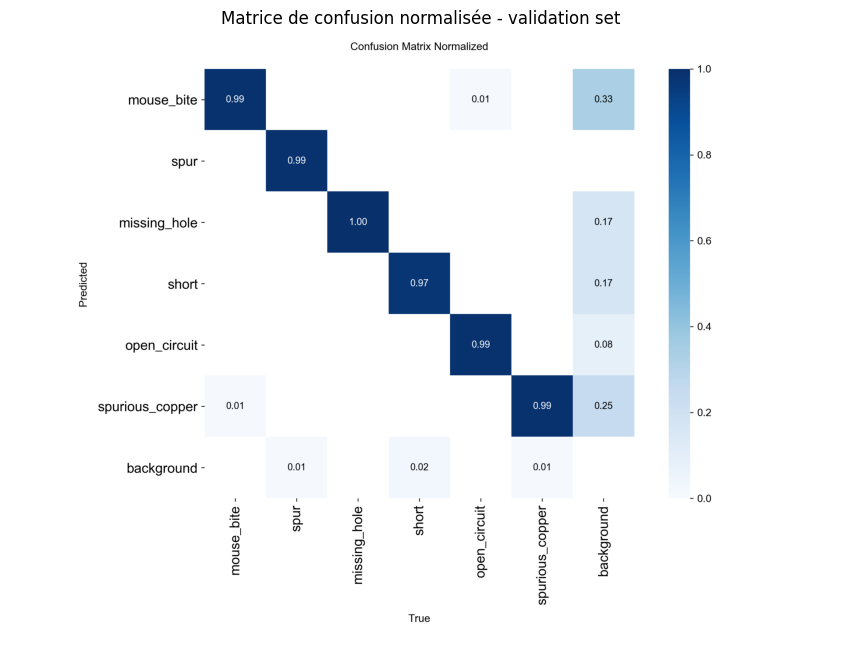

In [28]:
val_images_dir = dataset_root / "val" / "images"
num_val_images = len(list(val_images_dir.glob("*.jpg")))

print("Matrice de confusion avec le best model YOLO ci-dessous.")
print(f"Nombre d'images utilisées pour la matrice : {num_val_images}")

confusion_matrix_path = Path(confusion_results.save_dir) / "confusion_matrix_normalized.png"

img = plt.imread(confusion_matrix_path)

plt.figure(figsize=(11, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Matrice de confusion normalisée - validation set")
plt.show()

### 7.3.3. Per-class performance

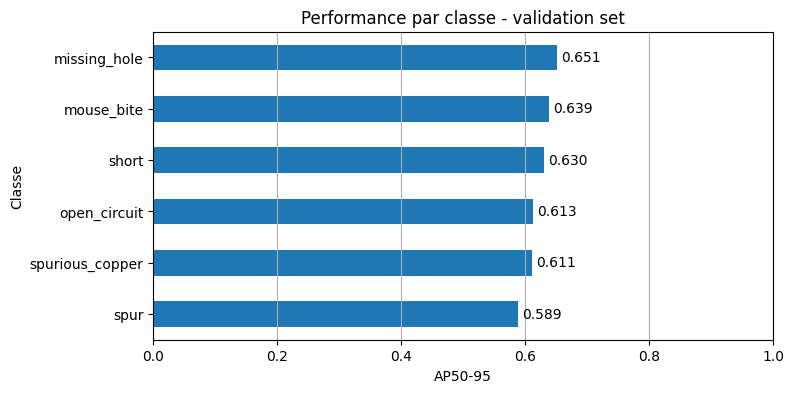

In [29]:
confusion_results.box.maps

per_class_df = pd.DataFrame(
    {
        "class_name": class_names,
        "ap50_95": confusion_results.box.maps,
    }
).sort_values("ap50_95")

ax = per_class_df.plot(
    x="class_name",
    y="ap50_95",
    kind="barh",
    figsize=(8, 4),
    legend=False,
)

plt.title("Performance par classe - validation set")
plt.xlabel("AP50-95")
plt.ylabel("Classe")
plt.xlim(0, 1)
plt.grid(axis="x")

# Ajout des valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.show()

# Sauvegarde
per_class_metrics_path = metrics_dir / "per_class_metrics.csv"
per_class_df.to_csv(per_class_metrics_path, index=False)

L’AP50-95 par classe tient compte de trois éléments :

- la capacité à détecter les défauts réels ;
- la limitation des détections signalées à tort ;
- la précision de localisation des boîtes, évaluée avec plusieurs seuils d’IoU entre 0,50 et 0,95.

Elle évalue donc à la fois la détection, la fiabilité des prédictions et la qualité de localisation.

👉 Les performances par classe restent ici relativement homogènes, avec un AP50-95 compris entre 0,589 et 0,651 selon les défauts.

# 8. Évaluation finale sur le jeu de test

In [30]:
test_results = best_model.val(
    data=str(dataset_yaml_path),
    split="test",
    imgsz=config["inference"]["image_size"],
    device=resolve_device(config["training"]["device"]),
    plots=True,
    project=str((experiment_root / "predictions").resolve()),
    name="test",
    exist_ok=True,
    verbose=False,
)

final_test_metrics_df = pd.DataFrame(
    [
        {
            "model_name": best_yolo_result["model_name"],
            "split": "test",
            "images": len(
                list((dataset_root / "test" / "images").glob("*.jpg"))
            ),
            "map50_95": float(test_results.box.map),
            "map50": float(test_results.box.map50),
            "precision": float(test_results.box.mp),
            "recall": float(test_results.box.mr),
            "inference_time": float(
                test_results.speed["inference"] / 1000
            ),
        }
    ]
)

final_test_metrics_df.to_csv(
    metrics_dir / "final_test_metrics.csv",
    index=False,
)

final_test_metrics_df

Ultralytics 8.4.26 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2 Max)
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 115.4±17.3 MB/s, size: 62.8 KB)
val: Scanning /Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/data/processed/pcb-defect-dataset/test/labels.cache... 266 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 266/266 278.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 2.6it/s 6.6s0.3s
                   all        266        552      0.964      0.991      0.985      0.608
Speed: 0.2ms preprocess, 4.0ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/outputs/predictions/test


,model_name,split,images,map50_95,map50,precision,recall,inference_time
0,yolov8s_epochs_20,test,266,0.607526,0.984991,0.964139,0.990977,0.004042


## 8.1 Matrice de confusion sur le jeu de test

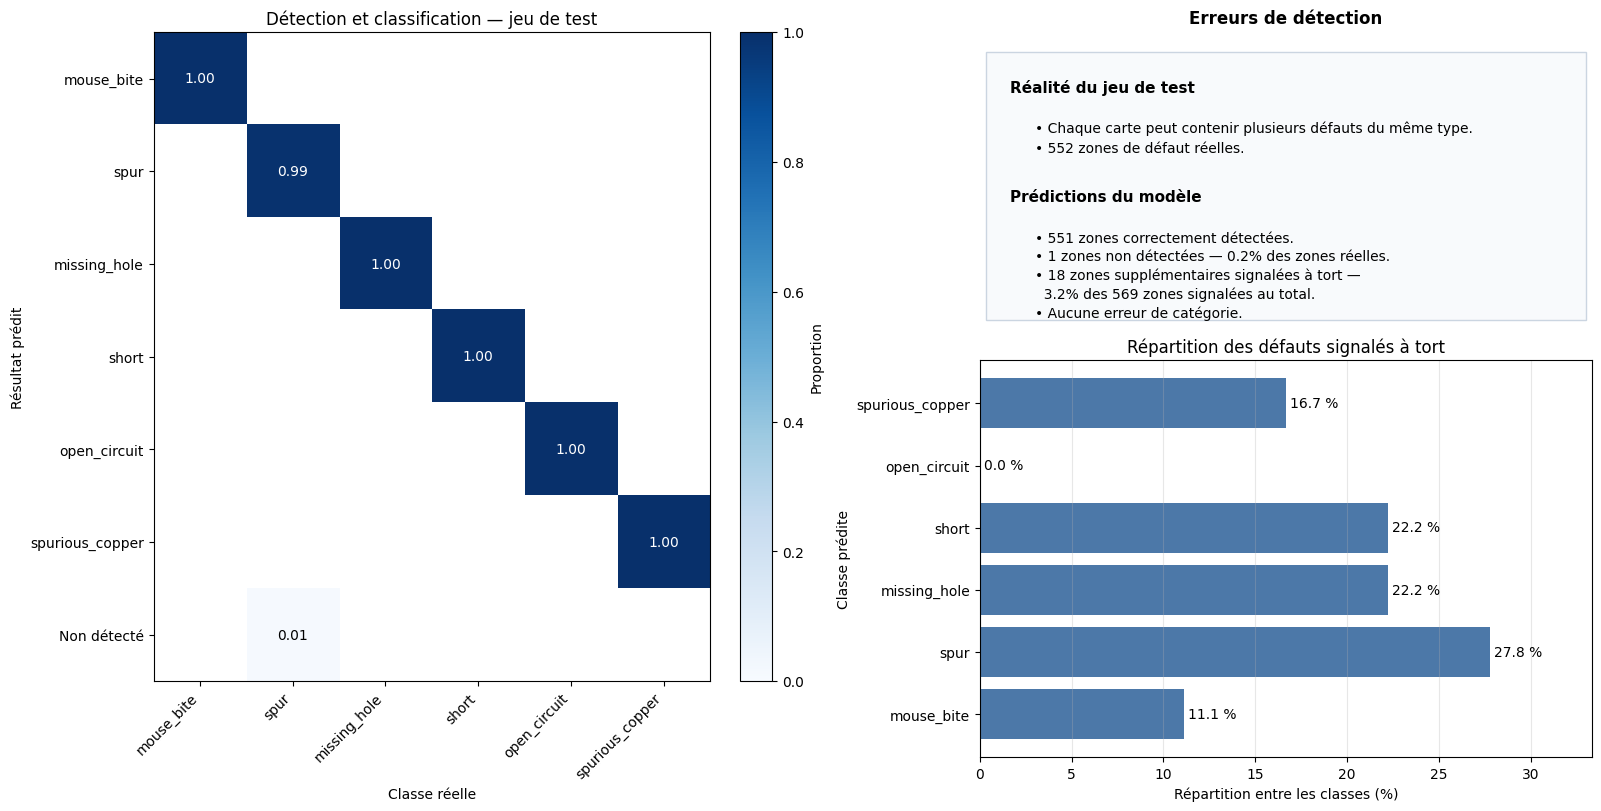

In [31]:
# Raw Ultralytics confusion matrix:
# rows = predictions, columns = true classes.
confusion_matrix = (
    test_results.confusion_matrix.matrix
    .astype(float)
)

class_matrix = confusion_matrix[:, :num_classes]

column_totals = class_matrix.sum(
    axis=0,
    keepdims=True,
)

readable_matrix = np.divide(
    class_matrix,
    column_totals,
    out=np.zeros_like(class_matrix),
    where=column_totals != 0,
)

masked_matrix = np.ma.masked_where(
    readable_matrix == 0,
    readable_matrix,
)

color_map = plt.colormaps["Blues"].copy()
color_map.set_bad("white")

predicted_labels = class_names + ["Non détecté"]


# Global detection errors.
actual_defects = class_matrix.sum()
missed_defects = confusion_matrix[-1, :num_classes].sum()

total_predictions = confusion_matrix[:num_classes, :].sum()
false_alerts_by_class = confusion_matrix[:num_classes, -1]
false_alerts = false_alerts_by_class.sum()

class_matrix_without_background = confusion_matrix[
    :num_classes,
    :num_classes,
]

class_confusions = (
    class_matrix_without_background.sum()
    - np.trace(class_matrix_without_background)
)

missed_rate = (
    missed_defects / actual_defects
    if actual_defects
    else 0.0
)

false_alert_rate = (
    false_alerts / total_predictions
    if total_predictions
    else 0.0
)

false_alert_distribution = np.divide(
    false_alerts_by_class,
    false_alerts,
    out=np.zeros_like(false_alerts_by_class),
    where=false_alerts != 0,
)

false_alert_percentages = (
    false_alert_distribution * 100
)


# Save the global error summary.
test_detection_errors_df = pd.DataFrame(
    [
        {
            "actual_defects": int(actual_defects),
            "missed_defects": int(missed_defects),
            "missed_rate": missed_rate,
            "total_predictions": int(total_predictions),
            "false_alerts": int(false_alerts),
            "false_alert_rate": false_alert_rate,
            "class_confusions": int(class_confusions),
        }
    ]
)

test_detection_errors_df.to_csv(
    metrics_dir / "final_test_detection_errors.csv",
    index=False,
)


# Save the distribution by predicted class.
false_alert_distribution_df = pd.DataFrame(
    {
        "class_name": class_names,
        "false_alerts": false_alerts_by_class.astype(int),
        "distribution": false_alert_distribution,
    }
)

false_alert_distribution_df.to_csv(
    metrics_dir / "final_test_false_alerts.csv",
    index=False,
)


# Build the complete diagnostic figure.
fig = plt.figure(
    figsize=(16, 8),
    constrained_layout=True,
)

main_grid = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.1, 1.4],
)

ax_matrix = fig.add_subplot(main_grid[0])

right_grid = main_grid[1].subgridspec(
    2,
    1,
    height_ratios=[0.75, 1],
)

ax_summary = fig.add_subplot(right_grid[0])
ax_false_alerts = fig.add_subplot(right_grid[1])


# Left: detection and classification matrix.
matrix_image = ax_matrix.imshow(
    masked_matrix,
    cmap=color_map,
    vmin=0,
    vmax=1,
)

ax_matrix.set_xticks(range(num_classes))
ax_matrix.set_xticklabels(
    class_names,
    rotation=45,
    ha="right",
)

ax_matrix.set_yticks(range(len(predicted_labels)))
ax_matrix.set_yticklabels(predicted_labels)

ax_matrix.set_xlabel("Classe réelle")
ax_matrix.set_ylabel("Résultat prédit")
ax_matrix.set_title(
    "Détection et classification — jeu de test"
)

for row_index in range(readable_matrix.shape[0]):
    for column_index in range(readable_matrix.shape[1]):
        value = readable_matrix[
            row_index,
            column_index,
        ]

        if value > 0:
            ax_matrix.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > 0.5
                    else "black"
                ),
            )

fig.colorbar(
    matrix_image,
    ax=ax_matrix,
    label="Proportion",
)


# Right top: explanation of the results.
correct_detections = np.trace(
    class_matrix_without_background
)

category_result = (
    "• Aucune erreur de catégorie."
    if class_confusions == 0
    else (
        f"• {int(class_confusions)} erreurs de catégorie."
    )
)

ax_summary.set_xlim(0, 1)
ax_summary.set_ylim(0, 1)
ax_summary.axis("off")

ax_summary.set_title(
    "Erreurs de détection",
    fontweight="bold",
)

# Background of the information box.
ax_summary.add_patch(
    plt.Rectangle(
        (0.01, 0.03),
        0.98,
        0.90,
        transform=ax_summary.transAxes,
        facecolor="#f8fafc",
        edgecolor="#cbd5e1",
        linewidth=1,
    )
)

ax_summary.text(
    0.05,
    0.84,
    "Réalité du jeu de test",
    transform=ax_summary.transAxes,
    fontsize=11,
    fontweight="bold",
    va="top",
)

ax_summary.text(
    0.09,
    0.70,
    (
        "• Chaque carte peut contenir plusieurs défauts du même type.\n"
        f"• {int(actual_defects)} zones de défaut réelles."
    ),
    transform=ax_summary.transAxes,
    fontsize=10,
    linespacing=1.5,
    va="top",
)

ax_summary.text(
    0.05,
    0.47,
    "Prédictions du modèle",
    transform=ax_summary.transAxes,
    fontsize=11,
    fontweight="bold",
    va="top",
)

ax_summary.text(
    0.09,
    0.33,
    (
        f"• {int(correct_detections)} zones correctement détectées.\n"
        f"• {int(missed_defects)} zones non détectées — "
        f"{missed_rate:.1%} des zones réelles.\n"
        f"• {int(false_alerts)} zones supplémentaires signalées à tort —\n"
        f"  {false_alert_rate:.1%} des "
        f"{int(total_predictions)} zones signalées au total.\n"
        f"{category_result}"
    ),
    transform=ax_summary.transAxes,
    fontsize=10,
    linespacing=1.4,
    va="top",
)


# Right bottom: distribution of incorrectly reported defects.
bars = ax_false_alerts.barh(
    class_names,
    false_alert_percentages,
    color="#4c78a8",
)

ax_false_alerts.set_title(
    "Répartition des défauts signalés à tort"
)
ax_false_alerts.set_xlabel(
    "Répartition entre les classes (%)"
)
ax_false_alerts.set_ylabel(
    "Classe prédite"
)
ax_false_alerts.grid(
    axis="x",
    alpha=0.3,
)

ax_false_alerts.set_xlim(
    0,
    max(
        1,
        false_alert_percentages.max() * 1.2,
    ),
)

ax_false_alerts.bar_label(
    bars,
    fmt="%.1f %%",
    padding=3,
)

diagnostics_path = (
    Path(test_results.save_dir)
    / "test_diagnostics.png"
)

fig.savefig(
    diagnostics_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Lecture de la matrice

- La diagonale montre que **99 à 100 % des défauts sont correctement classés** selon les catégories.
- **Une seule zone de défaut n’est pas détectée** : elle appartient à la classe `spur`. Cela représente **0,2 % des 552 zones réelles**.
- **Aucune confusion entre les six catégories** n’est observée.
- **18 zones supplémentaires sont signalées à tort**, soit **3,2 % des 569 zones signalées par le modèle**.
- La **précision globale de 96,4 %** confirme que les fausses alertes restent limitées.
- Le **rappel global de 99,1 %** indique que très peu de défauts réels échappent au modèle, ce qui est prioritaire pour le contrôle qualité.

## 8.2 Performance par classe sur le jeu de test

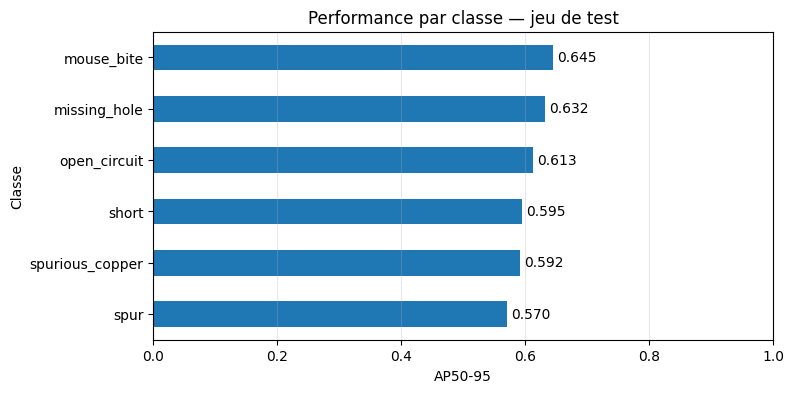

In [32]:
test_per_class_df = pd.DataFrame(
    {
        "class_name": class_names,
        "ap50_95": test_results.box.maps,
    }
).sort_values("ap50_95")

test_per_class_df.to_csv(
    metrics_dir / "final_test_per_class_metrics.csv",
    index=False,
)

ax = test_per_class_df.plot(
    x="class_name",
    y="ap50_95",
    kind="barh",
    figsize=(8, 4),
    legend=False,
)

plt.title("Performance par classe — jeu de test")
plt.xlabel("AP50-95")
plt.ylabel("Classe")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.show()

### Lecture du graphique

- L’AP50-95 mesure la qualité de détection pour chaque type de défaut.
- Elle tient compte de la classe prédite, de la détection du défaut et de la précision de sa localisation.
- Plus le score est proche de 1, plus le modèle détecte et localise correctement cette classe.

### Interprétation

- Les performances sont relativement homogènes entre les six classes.
- Aucune classe ne présente une dégradation majeure.
- Le modèle détecte légèrement mieux `mouse_bite` et `missing_hole`.
- `spur` reste la classe la plus difficile à localiser précisément.

# 9. Préparation des images pour la démonstration live

### Étapes

- Utilise les images et les annotations du jeu de test.
- Lit les labels YOLO pour identifier la classe réelle de chaque image.
- Sélectionne 2 images par classe, soit 12 images au total.
- Vérifie que chaque image contient un seul type de défaut.
- Copie uniquement les images originales dans `app/sample_images/originals/`.
- Ces images serviront ensuite d’entrées à la démonstration live via l’API.

In [33]:
test_images_dir = dataset_root / "test" / "images"
test_labels_dir = dataset_root / "test" / "labels"

demo_originals_dir = (
    project_root
    / "app"
    / "sample_images"
    / "originals"
)
demo_originals_dir.mkdir(
    parents=True,
    exist_ok=True,
)

images_per_class: dict[str, list[Path]] = defaultdict(list)

for label_path in sorted(test_labels_dir.glob("*.txt")):
    image_path = (
        test_images_dir
        / f"{label_path.stem}.jpg"
    )

    if not image_path.exists():
        raise FileNotFoundError(
            f"Missing image for {label_path.name}"
        )

    class_ids = {
        int(line.split()[0])
        for line in label_path.read_text(
            encoding="utf-8"
        ).splitlines()
        if line.strip()
    }

    if len(class_ids) != 1:
        raise ValueError(
            f"Expected one defect class in {label_path.name}."
        )

    class_name = class_mapping[next(iter(class_ids))]

    if len(images_per_class[class_name]) < 2:
        images_per_class[class_name].append(
            image_path
        )

for class_name in class_names:
    if len(images_per_class[class_name]) != 2:
        raise ValueError(
            f"Expected two demo images for {class_name}."
        )

    for image_index, image_path in enumerate(
        images_per_class[class_name],
        start=1,
    ):
        output_path = (
            demo_originals_dir
            / f"{class_name}_{image_index:02d}.jpg"
        )

        shutil.copy2(
            image_path,
            output_path,
        )

demo_images_count = len(
    list(demo_originals_dir.glob("*.jpg"))
)

print(
    "Images originales préparées pour la démonstration live :",
    demo_images_count,
)

Images originales préparées pour la démonstration live : 12


# 10. Mise à jour des ressources du dashboard

Cette section copie les métriques, le graphique de diagnostic et l’historique d’entraînement vers `app/assets/`.

In [34]:
app_assets_dir = project_root / "app" / "assets"
app_assets_dir.mkdir(parents=True, exist_ok=True)

assets_to_copy = {
    metrics_dir / "benchmark_results.csv":
        app_assets_dir / "benchmark_results.csv",
    metrics_dir / "yolo_tuning_results.csv":
        app_assets_dir / "yolo_tuning_results.csv",
    metrics_dir / "final_test_metrics.csv":
        app_assets_dir / "final_test_metrics.csv",
    metrics_dir / "final_test_per_class_metrics.csv":
        app_assets_dir / "final_test_per_class_metrics.csv",
    Path(test_results.save_dir) / "test_diagnostics.png":
        app_assets_dir / "test_diagnostics.png",
    best_run_results_path:
        app_assets_dir / "results.csv",
}

for source_path, target_path in assets_to_copy.items():
    if not source_path.exists():
        raise FileNotFoundError(
            f"Missing dashboard asset: {source_path}"
        )

    shutil.copy2(source_path, target_path)

print(
    "Ressources Streamlit mises à jour :",
    len(assets_to_copy),
)

Ressources Streamlit mises à jour : 6
